In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

from sklearn.metrics import root_mean_squared_error

------

# Linear regression assumptions

The purpose of this notebook is to outline the assumptions of the linear regression model and demonstrate why they are important. Note that the form of the 



---------

## 1. Linearity

Kind of obvious. We assume that the relationship between our predictors and our response is linear. If it is not then a simple linear regression model will not provide a very good fit to the data - see below an example of this.

This relates to discussions about estimating *f*, the true relationship between the predictors and the response, in chapter 2 of An Introduction to Statistical Learning. The linear regression model is a parametric method, meaning that it makes certain assumptions about the form of *f*, i.e. that it is linear. If *f* is not linear (or close to linear), then we can still fit a linear regression model but it will be a poor representation of *f* and any results will not be useful.

Below is an example of trying to fit a linear regression model to a dataset where the true relationship between the variables and the response is,

$ Y = (X - 0.5)^{2} + \epsilon $,

which is highly non-linear. Trying to fit a best-fit straight line to an equation of this form is clearly not going to go well, which is what we seee below.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                   0.02832
Date:                Sun, 16 Nov 2025   Prob (F-statistic):              0.867
Time:                        15:14:54   Log-Likelihood:                 112.05
No. Observations:                 100   AIC:                            -220.1
Df Residuals:                      98   BIC:                            -214.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0854      0.016      5.400      0.0

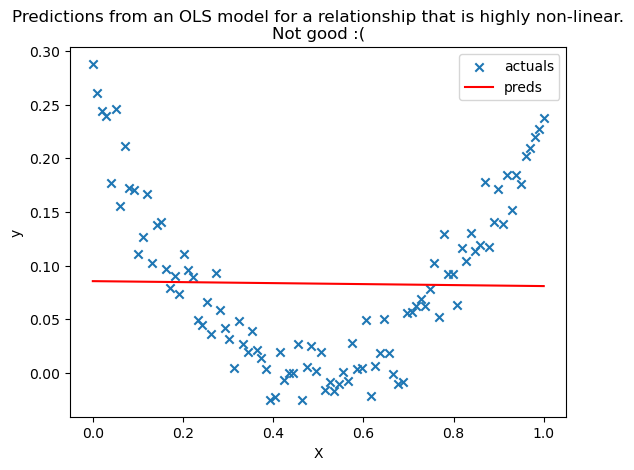

In [2]:
n_rows = 100

X = np.linspace(0, 1, n_rows)
Y = (X - 0.5)**2 + np.random.normal(0, 0.02, n_rows)

X_ = sm.add_constant(X)
model = sm.OLS(Y, X_).fit()
preds = model.predict(X_)

print(model.summary())

fig, ax = plt.subplots()
ax.scatter(X, Y, marker="x", label="actuals")
ax.plot(X, preds, color="r", label="preds")

ax.set_xlabel("X")
ax.set_ylabel("y")
ax.set_title("Predictions from an OLS model for a relationship that is highly non-linear.\nNot good :(")
ax.legend();

### 1.1 Transforming X to get a better fit

However, all is not lost. An important point is that we assume linearity between our response and our **predictors**. The variable *X* may not have a linear relationship but there is nothing to prevent us from transforming it into a form which *does* have a linear relationship.

Below we transform *X* with the equation $ X_{trans} = (X - 0.5)^{2} $ and then fit to this new variable - now we get a much better fit. Rather than the model coefficient relating directly to *X*, it relates to $ (X - 0.5)^{2} $. That is, we are choosing model coefficients, $\beta_{i}$, to minimise the sum of the residuals, where the assumed relationship is of the form,

$ f(X) = \beta_{0} + \beta_{1}*(X - 0.5)^{2} $.

We should interpret the estimated coefficient in this context.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.923
Model:                            OLS   Adj. R-squared:                  0.923
Method:                 Least Squares   F-statistic:                     1181.
Date:                Sun, 16 Nov 2025   Prob (F-statistic):           1.82e-56
Time:                        15:14:54   Log-Likelihood:                 240.47
No. Observations:                 100   AIC:                            -476.9
Df Residuals:                      98   BIC:                            -471.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0017      0.003     -0.502      0.6

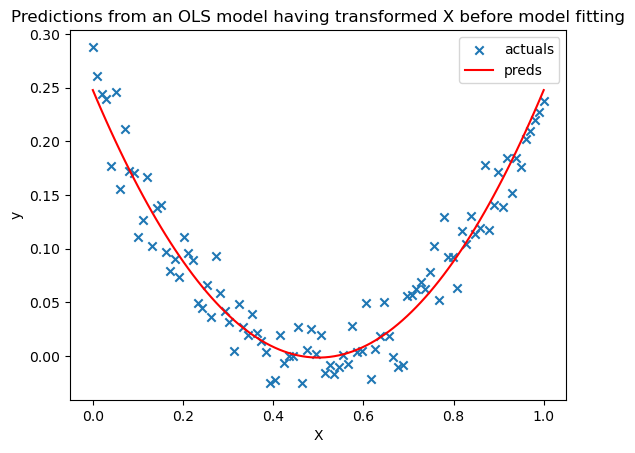

In [3]:
# now transform X so a linear regression model can be more useful
X_clean = (X - 0.5)**2

X_ = sm.add_constant(X_clean)
model = sm.OLS(Y, X_).fit()
preds = model.predict(X_)

print(model.summary())

fig, ax = plt.subplots()
ax.scatter(X, Y, marker="x", label="actuals")
ax.plot(X, preds, color="r", label="preds")

ax.set_xlabel("X")
ax.set_ylabel("y")
ax.set_title("Predictions from an OLS model having transformed X before model fitting")
ax.legend();

### 1.2 A more general approach to transforming variables

In this scenario we know the exact form of *f*, so it is trivial to transform *X* into a useful form. In the real world we do not always know what the true form of $f$ is so we cannot do this. The first step is visual: plotting $Y$ against each predictor (scatterplots, smooth trend lines) often reveals curvature, asymmetry, or diminishing returns that suggest candidate transformations. For example, multiplicative or diminishing-effect behaviour points toward logs; U-shapes point toward polynomials; sharp early increases that level off suggest square roots. Residual plots after an initial linear fit are equally valuable: systematic patterns in the residuals are a strong signal that the model needs additional structure.

From there, we typically iterate between modelling and checking. One route is to try a family of common transformations—polynomials of degree 2 or 3, logs, square roots—and evaluate improvements in fit and residual behaviour. Another route is to replace manual guessing with flexible tools such as splines or generalized additive models (GAMs), which allow the data to reveal its own shape. These methods can show you the smooth functional form, which you can then approximate using simpler engineered features if interpretability is important. In short, when the form of *f* is unknown, we discover it through visualisation, diagnostic checking, and the use of flexible models that expose the underlying structure before committing to a specific transformation.

Below is an example of how we can use the `PolynomialFeatures` class from sklearn. By fitting it to our data with `degree = 2`, we get an output array with three columns which contain a constant, the value of $X$, and of $X^{2}$. We then fit our linear regression model to this array and get some outputs. Because $ (X-0.5)^{2} = X^{2} - X + 0.25 $, this is exactly the same as fitting to $ (X-0.5)^{2} $ as in section 1.1, except that we get three coefficients rather than 1. We could also choose to increase the `degree` parameter to higher values, i.e. getting a polynomial of higher and higher powers, but in this case there is no need. This is an example of the trade-off between bias and variance. By increasing the complexity of the model through assuming a polynomial with higher powers, we will reduce the bias of the model but increase its variance. In this case a model with `degree > 2` will be fitting to the noise in the data, rather than capturing anything new about the true form of *f*. When we don't know the true form of *f*, we should look at how the performance of the model changes with increasing complexity; when the performance does not change with increased complexity, we should consider whether we are simply fitting to noise.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.922
Method:                 Least Squares   F-statistic:                     586.7
Date:                Sun, 16 Nov 2025   Prob (F-statistic):           6.55e-55
Time:                        15:14:55   Log-Likelihood:                 240.65
No. Observations:                 100   AIC:                            -475.3
Df Residuals:                      97   BIC:                            -467.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2500      0.007     38.392      0.0

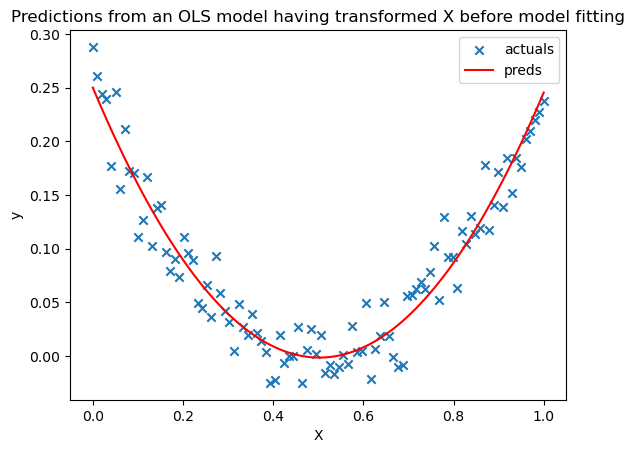

In [4]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(2)
X_clean = poly.fit_transform(X.reshape(-1, 1))

model = sm.OLS(Y, X_clean).fit()
preds = model.predict(X_clean)

print(model.summary())

fig, ax = plt.subplots()
ax.scatter(X, Y, marker="x", label="actuals")
ax.plot(X, preds, color="r", label="preds")

ax.set_xlabel("X")
ax.set_ylabel("y")
ax.set_title("Predictions from an OLS model having transformed X before model fitting")
ax.legend();

-----

## 2. Errors are independent of the predictors (exogeneity)

In a mathematical form, exogeneity is the following property,

$ \mathop{{}\mathbb{E}}[\epsilon | X] = 0 $

Here $ \epsilon $ is defined as the true error rather than the residuals, i.e. it is the term in the equation for the assumed form of the relationship between *X* and *Y*, $ Y = \beta_{0} + \beta_{1} * X + \epsilon $. $ \epsilon $ captures everything affecting *Y* that is not in the model, e.g. random noise, omitted variables, unmeasured influences, luck etc. The above equation therefore says that there is no relationship between the predictors and the errors, which means that once we know the predictors, there is no remaining systematic pattern in the error terms and the remaining error is just random noise. 

The reason that this matters is because of the way that the coefficients are calculated:

$ \hat{\beta_{1}} = \frac{Cov(X, Y)}{Var(X)}$

where $Y = \beta_{1}X + \epsilon$, so

$ Cov(X, Y) = \beta_{1}Var(X) + Cov(X, \epsilon) $

and

$ \hat{\beta_{1}} = \beta_{1} + \frac{Cov(X, \epsilon)}{Var(X)} $

Therefore, for $ \hat{\beta_{1}} = \beta_{1} $, we need $Cov(X, \epsilon) = 0$. If the true errors (not residuals) are correlated with the predictors, then we will get a biased coefficient. This means that the estimated coefficient is not equal to the true coefficient, even if we train many models over many random samples and take the average value of $\hat{\beta_{1}}$. Note that this not mean that our model is automatically a bad predictor, but it means that we cannot reliably use it for inference (this is the case with most of the linear regression assumptions).

An example of how the exogeneity assumption is violated is when there are two correlated predictors that each influence the response independently, but one of the predictors is omitted from the estimator. For example, both $LevelOfEducation$ and $Ability$ are predictors of $Salary$, and are also correlated with each other. If we only include one these predictors then we may assume a relationship of the form $Wage = \beta_{0} + \beta_{1}*LevelOfEducation + \epsilon$ where now the relationship between $Ability$ and $Salary$ is included in the error term. When we fit this model, we will attribute the effect of $Ability$ to the $LevelOfEducation$ variable, which means that the estimated coefficient for this variable will not be equal to the true value even when averaged over many samples, i.e. it is biased: $\hat{\beta}_{1} \neq \beta_{1}$. This is not necessarily an issue if we simply want our model to be a good predictor, however it can have implications for inference because we will not know the true relationship between our predictor and the target.

Another example is the relationship between the people being at the beach, ice cream sales and shark attacks. Fitting a model between IceCreamSales and SharkAttacks in the absence of PeopleBeingAtTheBeach would result in a non-zero coefficient. This illustrates the fact that we do not even need for the included variables to have a causal relationship with the target - only for the error term to contain information other than random noise.

We will reproduce an example such as the Salary example below. We create two correlated variables that both influence the response, $Y = \beta_{0} + \beta_{1}*X_{1} + \beta_{2}*X_{2} + \epsilon$, and ensure that $X_{1}$ and $X_{2}$ are correlated. When regressing on both variables, we see that the estimate for $\beta_{1}$ is very close to the true value, but it changes significantly when excluding it. Note that this is often a significant problem for inference but the consequences may not be so siginificant for prediction. By reducing the true coefficient for X2 in the codeblock below, we can reduce the difference between the RMSE of the full model and the partial model, whilst still having a significant impact on the estimated coefficient for X1. Depending on the use case for the linear regression model, a lack of exogeneity may not be such a big issue.

In [5]:
np.random.seed(666)

# Sample size
n = 100

# True model: Y depends on X1 and X2, where X2 is correlated with X1
X1 = np.random.normal(0, 1, n)
X2 = 0.7 * X1 + np.random.normal(0, 0.5, n)

# True coefficients
beta0, beta1, beta2 = 2, 3, 5

# Response variable with noise
eps = np.random.normal(0, 1, n)
Y = beta0 + beta1 * X1 + beta2 * X2 + eps

# --- Model 1: Uses both X1 and X2
X_full = sm.add_constant(np.column_stack([X1, X2]))
model_full = sm.OLS(Y, X_full).fit()
preds_full = model_full.predict(X_full)
rmse_full = root_mean_squared_error(Y, preds_full)

# --- Model 2: regress only with X1
X_partial = sm.add_constant(X1)
model_partial = sm.OLS(Y, X_partial).fit()
preds_partial = model_partial.predict(X_partial)
rmse_partial = root_mean_squared_error(Y, preds_partial)

df_results = pd.DataFrame(
    {
        "X1_coef": [beta1, model_full.params[1], model_partial.params[1]],
        "p-value": [np.NaN, model_full.pvalues[1], model_partial.pvalues[1]],
        "RMSE": [np.NaN, rmse_full, rmse_partial]
    }, index=["TrueValue", "FullModel", "PartialModel"]
)

df_results


,X1_coef,p-value,RMSE
TrueValue,3.000000,NaN,NaN
FullModel,3.119946,4.487980e-31,1.014542
PartialModel,6.808402,1.007570e-41,2.774252


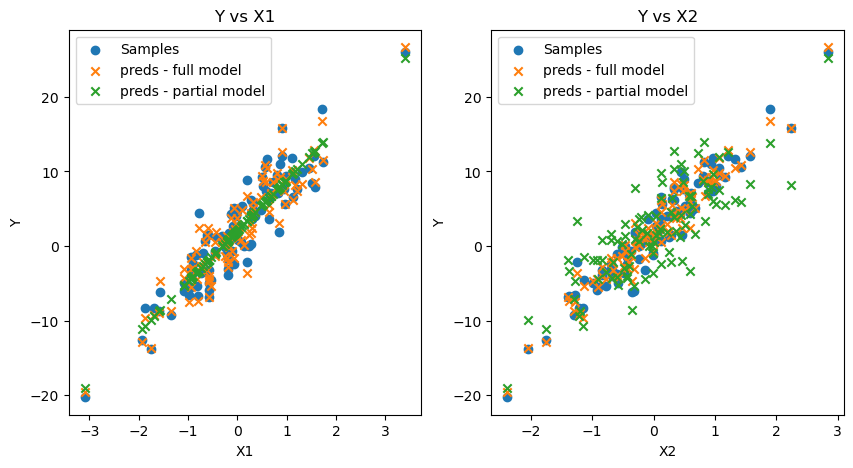

In [6]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 5))

ax1.scatter(X1, Y, label="Samples")
ax1.scatter(X1, preds_full, marker="x", label="preds - full model")
ax1.scatter(X1, preds_partial, marker="x", label="preds - partial model")

ax2.scatter(X2, Y, label="Samples")
ax2.scatter(X2, preds_full, marker="x", label="preds - full model")
ax2.scatter(X2, preds_partial, marker="x", label="preds - partial model")

for ax, x in zip((ax1, ax2), ("X1", "X2")):
    ax.set_xlabel(x)
    ax.set_ylabel("Y")
    ax.set_title(f"Y vs {x}")
    ax.legend()

--------

## 3. Constant variance across all error terms (homoscedasticity)

Meaning that the variance of the error term is constant across all values of $X$. Mathematically this is expressed as,

$ Var(\epsilon_{i} | X_{i}) = \sigma^{2} $ for all $i$

We can still fit to the data but the standard errors in the coefficients may be incorrect because the calculation of the variance in the coefficients assumes homoscedasticity and will therefore not return the correct answer. This leads to confidence intervals that are too narrow/wide and incorrect p-values. There are ways to handle scenarios where this assumption is violated. For example, we can use robust standard errors which are calculated in a way that does not assume homoscedasticity and will therefore return more realistic values. Note that heteroscedasticity does not lead to biased coefficients because we can still get the true value for our $\beta_{i}$ - this is only affected by the linearity and exogeneity conditions. 

An example of this assumption in action is if we are regressing income on education, where we would expect variance to increase as income increases. OLS will still find the best fit but we would end up over-trusting our predictions in the higher-variance (higher-income) regions.

Below we will generate data that has heteroscedastic errors and fit an OLS model to it. We will then use a hetereoscedasticity-robust covariance matrix to get a better estimate of the standard errors. This is a tool that can be used when the homoscedasticity assumption is violated. By using this, we get a higher standard error in our coefficients and a lower t-statistic. Though the result remains statistically significant, this example demonstrates how we might have a situation where we understate the standard errors and therefore overstate the t-statistic, potentially rejecting the null hypothesis when we should in fact be accepting it.

In [7]:
np.random.seed(666)

# Sample size
n = 500

# Predictor
X = np.random.normal(0, 5, n)

# Create heteroscedastic errors: variance grows with |X|
eps = np.random.normal(0, 1 + 2*abs(X), n)

# True model
beta0, beta1 = 2, 3
Y = beta0 + beta1*X + eps

# Fit OLS
X_design = sm.add_constant(X)
model_original = sm.OLS(Y, X_design).fit()

# Fit OLS with robust (HC3) standard errors
model_robust = model_original.get_robustcov_results(cov_type="HC3")


pd.DataFrame(
    [
        list(model.params) + [model.bse[-1], model.tvalues[-1]]
        for model in [model_original, model_robust]
    ], columns=[
        "Coef_X0",
        "Coef_X1",
        "StdError_X1",
        "t-statistic_X1",
    ], index=["OriginalModel", "RobustModel"]
)


,Coef_X0,Coef_X1,StdError_X1,t-statistic_X1
OriginalModel,1.908739,2.982971,0.088725,33.620595
RobustModel,1.908739,2.982971,0.148001,20.155130


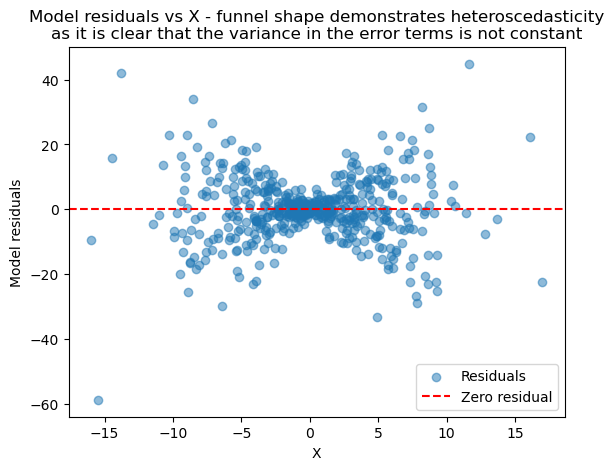

In [8]:
fig, ax = plt.subplots()

ax.scatter(X, model_original.resid, alpha=0.5, label="Residuals")
ax.axhline(0, color="red", linestyle="--", label="Zero residual")
ax.set_xlabel("X")
ax.set_ylabel("Model residuals")
ax.set_title("Model residuals vs X - funnel shape demonstrates heteroscedasticity\nas it is clear that the variance in the error terms is not constant");
ax.legend();

--------

## 4. Independence of the errors



--------

## 5. Normality of the errors

--------

## 6. Lack of multicollinearity

If our predictors exhibit strong/perfect multicollinearity then our coefficients become unstable and standard errors become inflated. This means that it becomes more difficult to make inference-based conclusions